Validation of data, use of new isotopes package, preliminary check w.r.t. rhodes and gisp2 data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hydra import initialize, compose
from pathlib import Path
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    colors_vibrant,
    fig_width_options,
)
from methane_noise_forcing import isotope
from methane_noise_forcing import io

plt.rcParams.update(matplotlib_rcparams)

# load data

In [2]:
## sapart
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(config_name="config")
data_dir = Path(cfg.paths.observations_root)

obs_sapart = pd.read_csv(
    data_dir / "raw/d13CH4 NEEM Sapart.txt",
    sep="\t",
    skiprows=4,
    names=["gas_age", "d13ch4"],
)
# sort descending by age
obs_sapart = obs_sapart.sort_values("gas_age", ascending=False).reset_index(drop=True)

obs_rhodes = io.load_observational_data("neem", **cfg.io["neem"].input)
obs_gisp2 = io.load_observational_data("gisp2", **cfg.io["gisp2"].input)

2025-10-16 15:54:40,750 - methane_noise_forcing.io - INFO - Loading NEEM data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/rhodesandbrook2019_neem.tab
2025-10-16 15:54:40,788 - methane_noise_forcing.io - INFO - Loading GISP2 data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_gisp2.csv


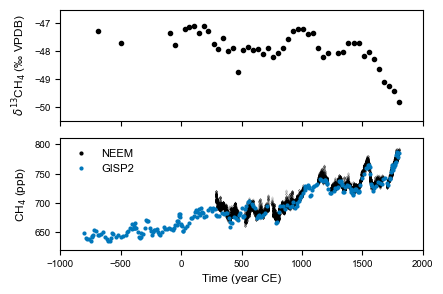

In [3]:
## plot
fig, axs = plt.subplots(
    2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True
)

axs[0].plot(
    obs_sapart["gas_age"],
    obs_sapart["d13ch4"],
    marker="o",
    markersize=3,
    linestyle="",
    color="k",
)
axs[0].set_ylim([-50.5, -46.5])
axs[0].set_ylabel(r"$\delta^{13}$CH$_4$ (‰ VPDB)")

axs[1].plot(
    obs_rhodes["gas_age"],
    obs_rhodes["ch4"],
    marker="o",
    markersize=0.05,
    linestyle="",
    label="NEEM",
    color="k",
)
axs[1].plot(
    obs_gisp2["gas_age"],
    obs_gisp2["ch4"],
    marker="o",
    markersize=2,
    linestyle="",
    label="GISP2",
    color=colors_vibrant["blue"],
)
axs[1].set_ylim([620, 810])
axs[1].set_ylabel("CH$_4$ (ppb)")
legend = axs[1].legend(frameon=False, fontsize=8)
legend.legend_handles[0].set_markersize(2)

axs[1].set_xlim([-1000, 2000])
axs[1].set_xlabel("Time (year CE)")

plt.tight_layout()

# infer the isotopic concentration of 13CH4
GISP2 from Mitchell et al. (2013) is essentially aligned with Rhodes et al. (2013) but is a longer record. We use the GISP2 bulk methane data to infer the 13CH4 concentration.

In [4]:
# interpolate the bulk CH4 data to the sapart ages
# sort increasing by age for interp1d
obs_gisp2_sorted = obs_gisp2.sort_values("gas_age", ascending=True).reset_index(
    drop=True
)
obs_gisp2_interp = obs_gisp2_sorted.set_index("gas_age")
ch4_bulk_interp = np.interp(
    obs_sapart["gas_age"], obs_gisp2_interp.index.values, obs_gisp2_interp["ch4"].values
)

ch4_13 = isotope.rare_13CH4_from_bulk_delta13C(
    bulk_CH4=ch4_bulk_interp,
    delta13C=obs_sapart["d13ch4"].values,
)
# add bulk ch4 and ch4_13 to dataframe
obs_sapart["ch4"] = ch4_bulk_interp
obs_sapart["12ch4"] = ch4_bulk_interp - ch4_13
obs_sapart["13ch4"] = ch4_13

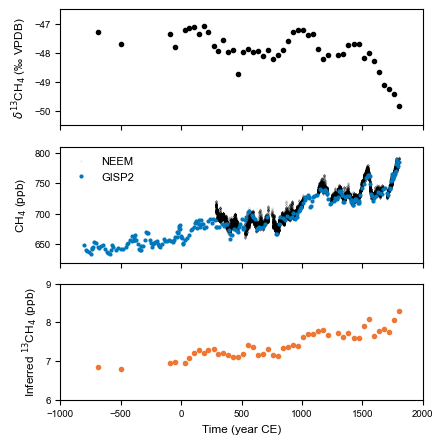

In [5]:
## plot
fig, axs = plt.subplots(
    3, 1, figsize=(fig_width_options["two_column_small"], 4.5), sharex=True
)

axs[0].plot(
    obs_sapart["gas_age"],
    obs_sapart["d13ch4"],
    marker="o",
    markersize=3,
    linestyle="",
    color="k",
)
axs[0].set_ylim([-50.5, -46.5])
axs[0].set_ylabel(r"$\delta^{13}$CH$_4$ (‰ VPDB)")

axs[1].plot(
    obs_rhodes["gas_age"],
    obs_rhodes["ch4"],
    marker="o",
    markersize=0.05,
    linestyle="",
    label="NEEM",
    color="k",
)
axs[1].plot(
    obs_gisp2["gas_age"],
    obs_gisp2["ch4"],
    marker="o",
    markersize=2,
    linestyle="",
    label="GISP2",
    color=colors_vibrant["blue"],
)
axs[1].set_ylim([620, 810])
axs[1].set_ylabel("CH$_4$ (ppb)")
legend = axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(
    obs_sapart["gas_age"],
    obs_sapart["13ch4"],
    marker="o",
    markersize=3,
    linestyle="",
    color=colors_vibrant["orange"],
)
axs[2].set_ylim([6, 9])
axs[2].set_ylabel(r"Inferred $^{13}$CH$_4$ (ppb)")

axs[2].set_xlim([-1000, 2000])
axs[2].set_xlabel("Time (year CE)")

plt.tight_layout()

In [6]:
## calculate mean and detrend data
mean_d13ch4 = obs_sapart["d13ch4"].mean()
mean_ch4 = obs_sapart["ch4"].mean()
mean_12ch4 = obs_sapart["12ch4"].mean()
mean_13ch4 = obs_sapart["13ch4"].mean()

# calculate linear trend and detrend
for col in ["d13ch4", "ch4", "13ch4", "12ch4"]:
    p = np.polyfit(obs_sapart["gas_age"], obs_sapart[col], 1)
    trend = np.polyval(p, obs_sapart["gas_age"])
    obs_sapart[f"{col}_anomaly"] = obs_sapart[col] - trend

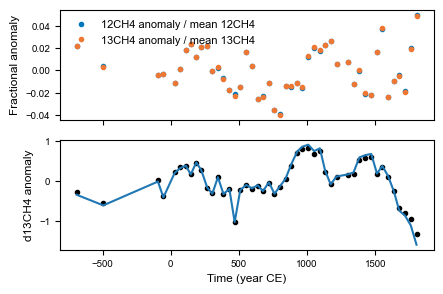

In [7]:
## see if the fractional anomalies add up
ch4_12_frac_anomaly = obs_sapart["12ch4_anomaly"] / mean_12ch4
ch4_13_frac_anomaly = obs_sapart["13ch4_anomaly"] / mean_13ch4
inferred_13ch4_anomaly = (ch4_13_frac_anomaly - ch4_12_frac_anomaly) * 1000

fig, axs = plt.subplots(
    2, 1, figsize=(fig_width_options["two_column_small"], 3), sharex=True
)

axs[0].plot(
    obs_sapart["gas_age"],
    obs_sapart["12ch4_anomaly"] / mean_12ch4,
    label="12CH4 anomaly / mean 12CH4",
    marker="o",
    markersize=3,
    linestyle="",
    color=colors_vibrant["blue"],
)
axs[0].plot(
    obs_sapart["gas_age"],
    obs_sapart["13ch4_anomaly"] / mean_13ch4,
    label="13CH4 anomaly / mean 13CH4",
    marker="o",
    markersize=3,
    linestyle="",
    color=colors_vibrant["orange"],
)
axs[0].set_ylabel("Fractional anomaly")
axs[0].legend(frameon=False, fontsize=8)

axs[1].plot(
    obs_sapart["gas_age"],
    obs_sapart["d13ch4_anomaly"],
    label="d13CH4 anomaly",
    marker="o",
    markersize=3,
    linestyle="",
    color="k",
)
axs[1].plot(
    obs_sapart["gas_age"],
    inferred_13ch4_anomaly,
)
axs[1].set_ylabel("d13CH4 anomaly")
axs[1].set_xlabel("Time (year CE)")

plt.tight_layout()